In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison

## Analysis of Larger experiments


In [2]:
bpr_unbiased_calibrated_time = "experiments/ml/bpr_unbiased_calibrated_time_based_large.yaml"
bpr_unbiased_calibrated_steck = "experiments/ml/bpr_unbiased_calibrated_constant_large.yaml"

bpr_debiased = "experiments/ml/bpr_unbiased_uncalibrated_large.yaml"

random_rec = "experiments/ml/random_rec_uncalibrated_large.yaml"
most_popular = "experiments/ml/most_popular_uncalibrated_large.yaml"

### Analise do MAP


Mesmo pra n maior, ta esquisito. Talvez seja um problema de como eu avalio esse cara

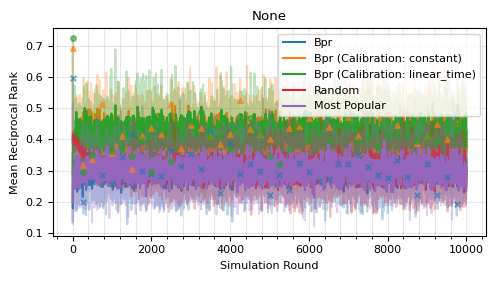

In [3]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="mrr", title=None, graph="line", plot_retrain_points=True,  window_size=5)

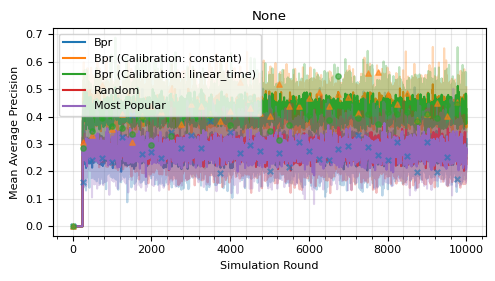

In [4]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="map", title=None, graph="line", plot_retrain_points=True,  window_size=5)

### Taste distortion between recommendation and initial state



Conclusões bem parecidas em relação ao N pequeno: calibração cai ao longo do tempo. Curiosamente calibração ficou pior pro caso do yelp. 

A mesma conclusão não ocrre pro MACE. Então deve ser algo rank-sensitive. Talvez a lista como um todo esteja mais mal calibrada, mas o top5 esteja bom?

Agora sem o random

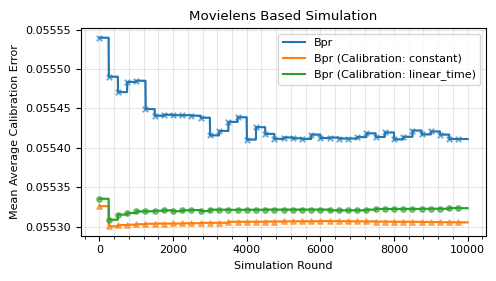

In [5]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="mace", title="Movielens Based Simulation", graph="line", plot_retrain_points=True,  window_size=5, should_remove_outliers=False)

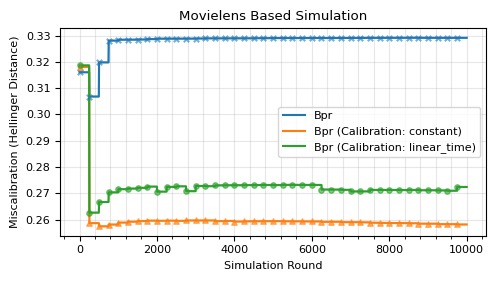

In [10]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="diver", title="Movielens Based Simulation", graph="line", plot_retrain_points=True,  should_remove_outliers=False, window_size=5, figsize = (5,3), y_label="Miscalibration (Hellinger Distance)")

While all variants of BPR start with a similar distortion towards the users initial preference, after a a few interactions and around 3 retraining cycles, the models learn the users behaviors. However, while uncalibrated BPR gets even more uncalibrated, the calibrated versions stay closer to what the user has interacted initially. This shows that calibrating recommendations constantly might diminish taste distortion even further through time, until it eventually stabilizes. As Da Silva et al 2025 pointed, we also see little to no difference between time based and constant calibration for movielens.

### Analisando diversidade

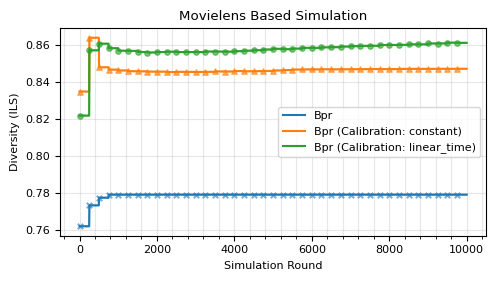

In [13]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="div", title="Movielens Based Simulation", graph="line", plot_retrain_points=True,  window_size=5)

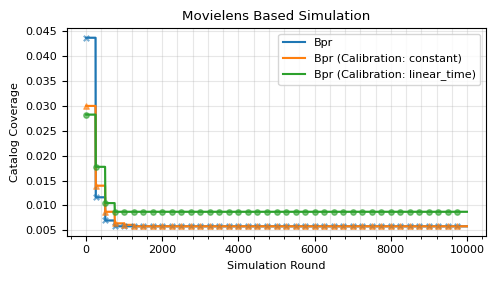

In [11]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="coverage", title="Movielens Based Simulation", graph="line", plot_retrain_points=True,  window_size=5)

## Analisando viés de popularidade

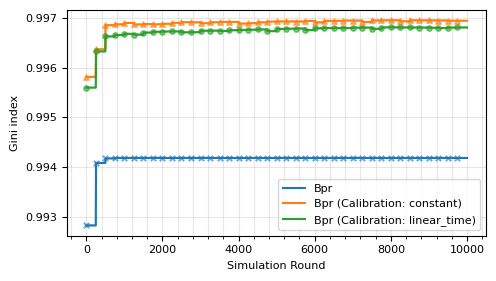

In [9]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="gini", title="", graph="line", plot_retrain_points=True,  window_size=5)